# k-최근접 이웃 회귀

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/03-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

## 데이터 준비

In [77]:
import numpy as np

In [78]:
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [79]:
import matplotlib.pyplot as plt

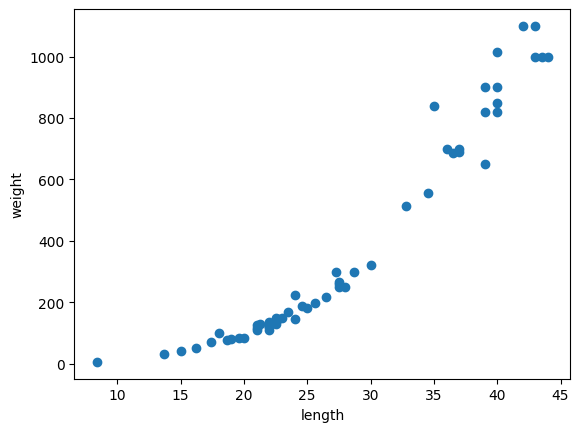

In [80]:
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show() #회귀는 임의의 실수를 예측하기때문에 마커로 표시할 수 없다 ?

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
train_input, test_input, train_target, test_target = train_test_split( #여기서는 stratify 함수 사용할 필요없고 랜덤하게 섞음
    perch_length, perch_weight, random_state=42) #target은 1차원 배열해도 됌 input데이터는 2차원 배열로 꼭 전달해야함 reshape를 써서 2차원 배열로 만듦

In [83]:
print(train_input.shape, test_input.shape)

(42,) (14,)


In [84]:
test_array = np.array([1,2,3,4])
print(test_array.shape)

(4,)


In [85]:
test_array = test_array.reshape(2, 2)
print(test_array.shape)

(2, 2)


In [86]:
# 아래 코드의 주석을 제거하고 실행하면 에러가 발생합니다
# test_array = test_array.reshape(2, 3)

In [87]:
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [88]:
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


## 결정 계수 ($ R^2$)

In [89]:
from sklearn.neighbors import KNeighborsRegressor

In [90]:
knr = KNeighborsRegressor()
# k-최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target) #fit 함수로 훈련세트를 전달하고

KNeighborsRegressor()

In [91]:
knr.score(test_input, test_target) #테스트 세트를 score함수로 평가하면 된다.

0.992809406101064

In [92]:
from sklearn.metrics import mean_absolute_error #절댓값으로 실제로 얼마만큼 차이가 나는지 평균적으로 보는 것

In [93]:
# 테스트 세트에 대한 예측을 만듭니다
test_prediction = knr.predict(test_input)
# 테스트 세트에 대한 평균 절댓값 오차를 계산합니다
mae = mean_absolute_error(test_target, test_prediction)
print(mae) #평균적으로 19.157142857142862g 차이가 있다는 것을 알 수 있음

19.157142857142862


## 과대적합 vs 과소적합

In [94]:
print(knr.score(train_input, train_target)) #훈련 데이터로 훈련하고 테스트 점수가 더 높으면 과소적합 반대로 훈련세트가 반대로 너무 높으면 과대 적합

0.9698823289099254


In [95]:
# 이웃의 갯수를 3으로 설정합니다
knr.n_neighbors = 3
# 모델을 다시 훈련합니다
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))

0.9804899950518966


In [99]:
print(knr.score(test_input, test_target))

0.9737908255822255


## 확인문제

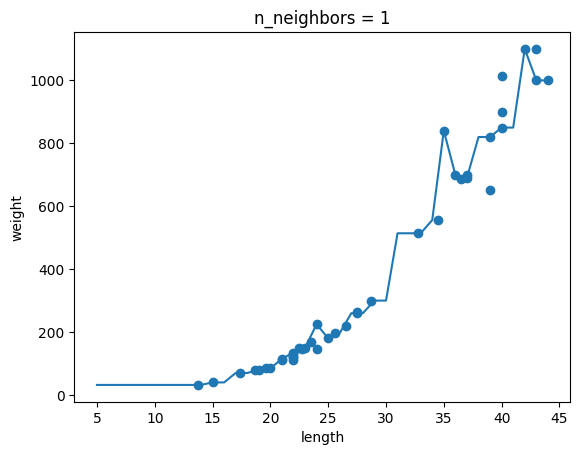

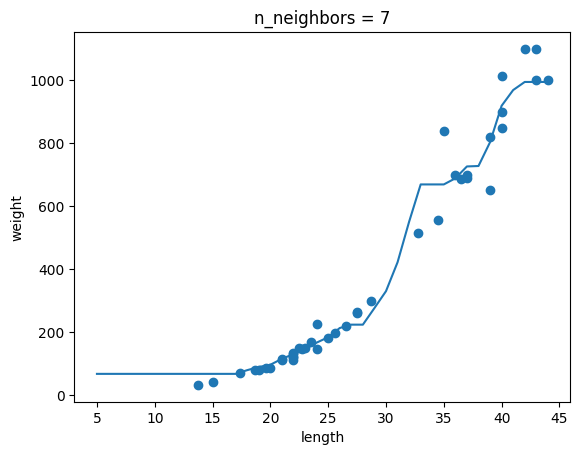

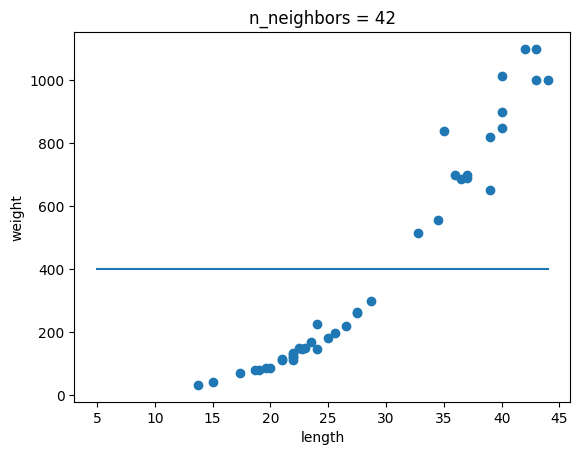

In [105]:
# k-최근접 이웃 회귀 객체를 만듭니다
knr = KNeighborsRegressor()
# 5에서 45까지 x 좌표를 만듭니다
x = np.arange(5, 45).reshape(-1, 1)

# n = 1, 5, 10일 때 예측 결과를 그래프로 그립니다.
for n in [1, 7, 42]:
    # 모델 훈련
    knr.n_neighbors = n
    knr.fit(train_input, train_target)
    # 지정한 범위 x에 대한 예측 구하기
    prediction = knr.predict(x)
    # 훈련 세트와 예측 결과 그래프 그리기
    plt.scatter(train_input, train_target)
    plt.plot(x, prediction)
    plt.title('n_neighbors = {}'.format(n))
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()